In [46]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cmocean
from flow import sample_images
from utils import load_checkpoint
from torchdiffeq import odeint
import time
from torch import optim
from torchmetrics import CatMetric
from unet_v2 import UnetV2



In [47]:
# torch.manual_seed(159753)
# np.random.seed(159753)

torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cuda.enable_flash_sdp(True)
torch.backends.cuda.enable_mem_efficient_sdp(True)
torch.backends.cuda.enable_math_sdp(True)


In [48]:

%%capture
im_size = 128
problem = "eit-circles-easy"
ckp_index = 37750
checkpoint_path = f'problems/{problem}/checkpoints/ckp_{ckp_index}.tar'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# match the number of channels to your model
model = UnetV2(ch=32).to(device)

_, _, model, _, _, _= load_checkpoint(model=model, path=checkpoint_path)
model.eval()

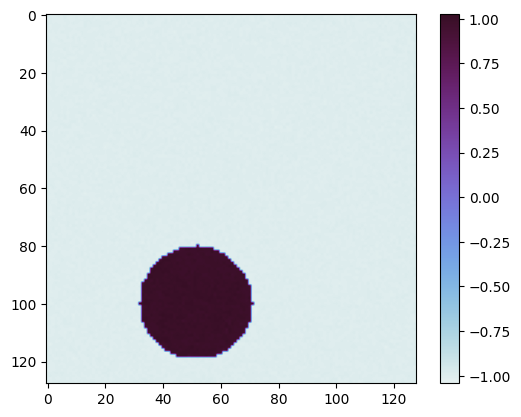

In [49]:
# test model out quickly
# with torch.autograd.profiler.profile(use_device='cuda') as prof:
img = sample_images(model, (1,1,im_size,im_size), num_steps=5, device=device)
# print(prof.key_averages().table(sort_by="cuda_time_total"))
img = img[-1].squeeze().cpu().numpy()
plt.imshow(img, cmap=cmocean.cm.dense)
plt.colorbar() # note that our flow model is normalized to [-1,1]

In [50]:
from typing import Callable, Dict, List, Optional

from torch import autocast
from torchdiffeq import odeint_adjoint 
import torch.nn as nn


def loss_fn(x, y, media, lambda_reg=1e-2):
    """
    Loss function with Tikhonov (L2) regularization.
    
    Args:
        x: predicted values
        y: target values  
        lambda_reg: regularization parameter
    """
    data_loss = torch.sqrt(torch.sum(torch.square(x - y)))
    
    # Tikhonov regularization term (L2 norm of x)
    reg_loss = lambda_reg * torch.norm(media, p=2)**2
    
    # Total loss
    total_loss = data_loss + reg_loss
    
    return total_loss

def ode_integrate(ode_func: nn.Module,
                  init_x: torch.Tensor,
                  ode_opts: Dict = {},
                  t_eps: float = 0,
                  init_t: float = 0.,
                  final_t: float = 1.,
                  t_arr: Optional[List[float]] = None,
                  num_steps: int = 5,
                  intermediate_points: bool = False
      ) -> torch.Tensor:

    if t_arr is None:
        t = torch.linspace(init_t - t_eps, final_t, num_steps).to(init_x.device)
    else:
        t = torch.tensor(t_arr, dtype=torch.float32, device=init_x.device)

    ode_opts = {
        "atol": 1e-5, 
        "rtol": 1e-5, 
        "method": "dopri5", # "dopri5", "rk4", "euler", "adams", "bdf"
        **ode_opts
    }

    z = odeint(
        func = lambda t, x: ode_func(x, t.expand(x.shape[0])),
        y0 = init_x,
        t = t,
        **ode_opts
    )

    if not intermediate_points:
        return z[-1]
    return z


In [51]:

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(num_params)


1729793


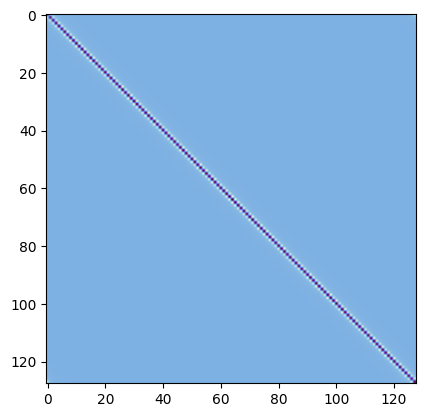

In [52]:
# load data and select a random ground truth from test set
import os
from forward_solvers.dtn_from_sigma import dtn_from_sigma
from forward_solvers.fem import Mesh, V_h
from scipy import io as sio
import cmocean as cmo
test_data = torch.load(f'data/{problem}-dataset-{im_size}.pt')["test"]
idx = 70
gt = test_data[idx].to(device).unsqueeze(0)

# load mesh
data_root = 'forward_solvers/mesh-data'
mesh_file = 'mesh_128_h05.mat'
img_size = 128
original_size = 128
pad_size = 0

mat_fname  = os.path.join(data_root, mesh_file)
mat_contents = sio.loadmat(mat_fname)

p = torch.tensor(mat_contents['p'], dtype=torch.float64).to(device)
t = torch.tensor(mat_contents['t']-1, dtype=torch.long).to(device)
vol_idx = torch.tensor(mat_contents['vol_idx'].reshape((-1,))-1, dtype=torch.long).to(device)
bdy_idx = torch.tensor(mat_contents['bdy_idx'].reshape((-1,))-1, dtype=torch.long).to(device)

mesh = Mesh(p, t, bdy_idx, vol_idx)
v_h = V_h(mesh)

# get the dtn map
dtn_map = dtn_from_sigma(sigma_vec=gt, v_h=v_h, mesh=mesh, img_size=img_size, device=device)

plt.imshow(dtn_map.reshape((img_size, img_size)).cpu().detach().numpy(), cmap=cmo.cm.dense)


In [53]:
background = torch.ones(im_size, im_size).to(device)
background_dtn = dtn_from_sigma(sigma_vec=background, v_h=v_h, mesh=mesh, img_size=img_size, device=device)
print(background_dtn.min(), background_dtn.max())
# check if there are any zeros
print((background_dtn==0).sum())

tensor(-0.6623, device='cuda:0', dtype=torch.float64) tensor(1.6742, device='cuda:0', dtype=torch.float64)
tensor(0, device='cuda:0')


In [54]:
# getting normalization constants
train_min, train_max = torch.min(torch.load(f'data/{problem}-dataset-{im_size}.pt')["train"]), torch.max(torch.load(f'data/{problem}-dataset-{im_size}.pt')["train"])

Frobenius distance between two random media samples: 0.2557118683494401


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

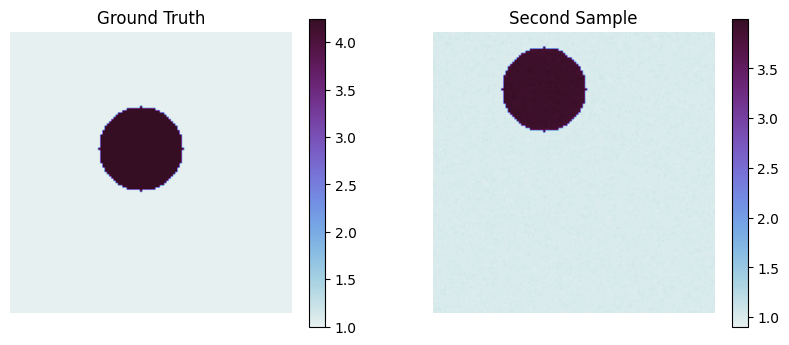

In [55]:
x0_gaussian = torch.randn((1,1,im_size,im_size)).to(device)
with torch.no_grad():
    snd_sample = ode_integrate(model, x0_gaussian, num_steps=5)
snd_sample =  0.5 * (snd_sample + 1.0) * (train_max - train_min) + train_min
snd_dtn_map = dtn_from_sigma(
    sigma_vec=snd_sample, v_h=v_h, mesh=mesh, img_size=img_size, device=device
)
cost = loss_fn(dtn_map, snd_dtn_map, snd_sample, lambda_reg=0).item()
print(f"Frobenius distance between two random media samples: {cost}")
# plot the two side by side
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.imshow(gt.squeeze().cpu(), cmap=cmocean.cm.dense)
plt.colorbar()
plt.title('Ground Truth')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(snd_sample.detach().squeeze().cpu(), cmap=cmocean.cm.dense)
plt.colorbar()
plt.title('Second Sample')
plt.axis('off')



In [64]:
max_iter = 20
optim_steps = 1000
target_cost = 1e-4
time_limit = 500
lr = .005
x1_trajectory = []
dtn_trajectory = []
init_x = torch.randn((1, 1, im_size, im_size), device=device, dtype=torch.float32)
# init_x = gt_gaussian.unsqueeze(0).unsqueeze(0).to(device)
init_x.requires_grad = True
# y = dtn_map / background_dtn
y = dtn_map
# optimizer = optim.LBFGS([init_x], max_iter=max_iter, lr=lr, history_size=10)
optimizer = torch.optim.SGD([init_x], lr=lr, nesterov=True, momentum=0.9)
# optimizer = optim.Adam([init_x], lr=lr, betas=(0.9, 0.99), eps=1e-8, weight_decay=0.01)


start_time = time.time()
# add metrics to tqdm
for step in range(optim_steps):
    def closure():
        global loss
        global x1
        global dtn_trajectory
        optimizer.zero_grad()

        ### solve for x1
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            x1 = ode_integrate(ode_func=model, init_x=init_x, num_steps=5)
        # unnormalize x1
        x1 = 0.5 * (x1 + 1.0) * (train_max - train_min) + train_min
        
        measurement = dtn_from_sigma(sigma_vec=x1, v_h=v_h, mesh=mesh, img_size=img_size, device=device)
        # measurement = measurement / background_dtn 
        dtn_trajectory.append(measurement.detach().cpu().numpy())

        loss = loss_fn(measurement, y, x1)

        loss.backward()
        return loss


    optimizer.step(closure)
    


    x1_trajectory.append(x1.detach().cpu().numpy())

     # print metrics


    elapsed = time.time() - start_time

    elapsed = elapsed/60
    print(f"[Step {step}] Loss {loss.item()}"
        + f"| time: {elapsed} mins")

    if target_cost is not None:
        if loss.item() <= target_cost:
            print(f"reached cost of {loss.item()}")
            break 

    if time_limit is not None:
        elapsed = (time.time() - start_time)/60 # time in minutes
        if elapsed > time_limit:
            print(f'reached time limit of {time_limit} mins')
            break

with torch.no_grad():
    x1 = ode_integrate(model, init_x)
    x1 = 0.5 * (x1 + 1.0) * (train_max - train_min) + train_min
x1_trajectory.append(x1.detach().cpu().numpy())



[Step 0] Loss 312.07633964083476| time: 0.07322401603062947 mins
[Step 1] Loss 261.1359879464354| time: 0.15040297508239747 mins
[Step 2] Loss 352.72771696947933| time: 0.22876341342926027 mins
[Step 3] Loss 298.6414398495407| time: 0.30365900993347167 mins
[Step 4] Loss 299.5127385638568| time: 0.3778181910514832 mins
[Step 5] Loss 298.5681990463669| time: 0.45357205470403034 mins
[Step 6] Loss 293.98244395017605| time: 0.527792771657308 mins
[Step 7] Loss 290.3554921254627| time: 0.6023973385492961 mins
[Step 8] Loss 282.80251351793606| time: 0.6773436784744262 mins
[Step 9] Loss 312.496811028465| time: 0.7508084853490193 mins
[Step 10] Loss 283.23828819808125| time: 0.8257071654001872 mins
[Step 11] Loss 274.5908754876304| time: 0.9002862453460694 mins
[Step 12] Loss 273.54197077133466| time: 0.9747090657552083 mins
[Step 13] Loss 271.55885232312926| time: 1.0497145215670267 mins
[Step 14] Loss 268.71676397432907| time: 1.124576751391093 mins
[Step 15] Loss 264.6933916883629| time: 

KeyboardInterrupt: 

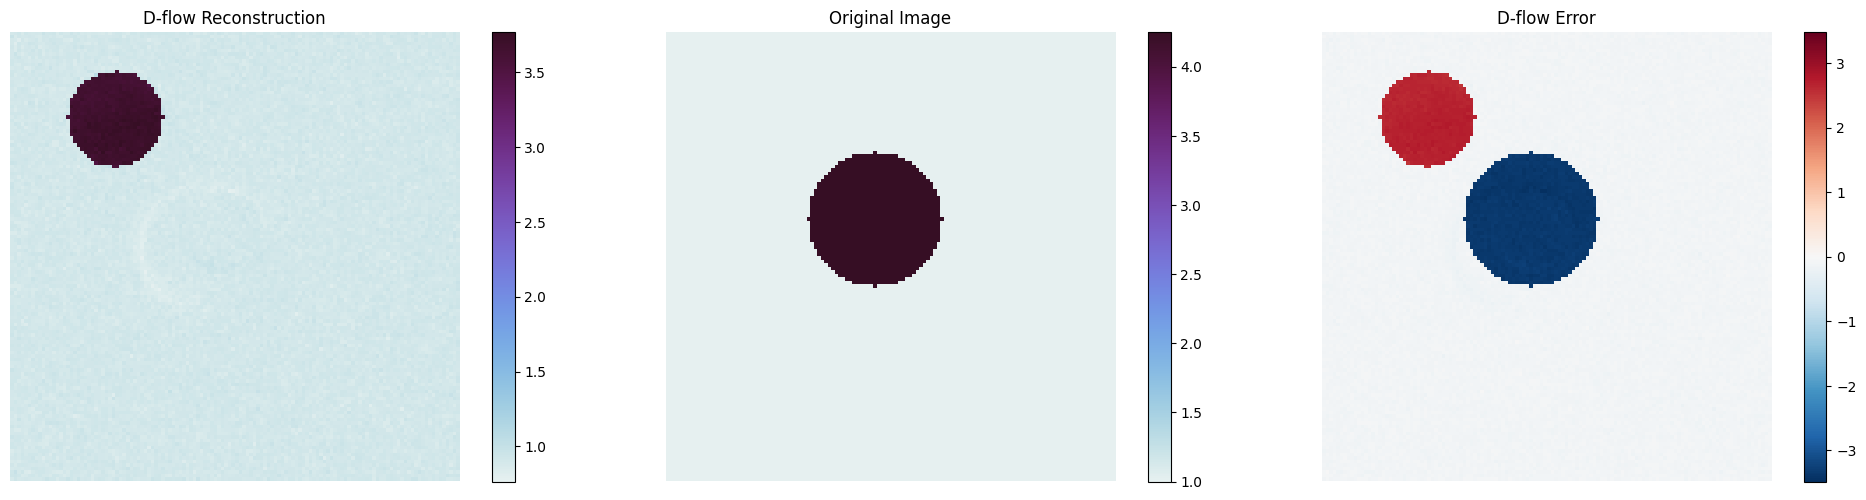

D-flow Results
MSE: 1.032595
MAE: 0.411756
PSNR: 12.43 dB
Rel. L2 Error: 0.6889


In [65]:
import warnings

# Suppress warnings from transforms
warnings.filterwarnings('ignore', category=RuntimeWarning)
np.seterr(divide='ignore', invalid='ignore')

# plot error and final result
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Reconstructed image (D-flow)
im1 = axes[0].imshow(x1.squeeze().detach().cpu().numpy(), cmap=cmocean.cm.dense)
axes[0].set_title('D-flow Reconstruction')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0])


# Original image
im3 = axes[1].imshow(gt.squeeze().cpu().numpy(), cmap=cmocean.cm.dense)
axes[1].set_title('Original Image')
axes[1].axis('off')
plt.colorbar(im3, ax=axes[1])

# Error/difference (D-flow vs Original)
error = x1.squeeze().detach().cpu().numpy() - gt.squeeze().cpu().numpy()
im4 = axes[2].imshow(error, cmap='RdBu_r', vmin=-np.abs(error).max(), vmax=np.abs(error).max())
axes[2].set_title('D-flow Error')
axes[2].axis('off')
plt.colorbar(im4, ax=axes[2])

plt.tight_layout()
plt.show()

# Print comparison metrics
mse_dflow = np.mean(error**2)
mae_dflow = np.mean(np.abs(error))
psnr_dflow = 20 * np.log10(np.max(gt.squeeze().cpu().numpy()) / np.sqrt(mse_dflow))

print("D-flow Results")
print(f"MSE: {mse_dflow:.6f}")
print(f"MAE: {mae_dflow:.6f}")
print(f"PSNR: {psnr_dflow:.2f} dB")
print(f"Rel. L2 Error: {np.linalg.norm(error) / np.linalg.norm(gt.squeeze().cpu().numpy()):.4f}")


In [66]:
import matplotlib.animation as animation
from IPython.display import HTML

# Create animation of x1 trajectory
fig, ax = plt.subplots(figsize=(8, 8))

def animate(frame):
    ax.clear()
    img = x1_trajectory[frame].squeeze()
    im = ax.imshow(img, cmap=cmocean.cm.dense, vmin=img.min(), vmax=img.max())
    ax.set_title(f'D-flow Reconstruction - Step {frame}', fontsize=14)
    ax.axis('off')
    return [im]

# Sample every 10th frame to make animation smoother and smaller
frame_indices = list(range(0, len(x1_trajectory), max(1, len(x1_trajectory) // 50)))
if len(frame_indices) > 100:  # Limit to 100 frames max
    frame_indices = frame_indices[::len(frame_indices)//100]

# Create animation
anim = animation.FuncAnimation(fig, animate, frames=frame_indices, 
                             interval=200, blit=False, repeat=True)

plt.close(fig)  # Close the figure to prevent blank canvas display

# Convert to HTML5 video for inline playback
html_anim = HTML(anim.to_jshtml())
html_anim

In [67]:
# Create side-by-side comparison animation
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

gt_img = gt.squeeze().cpu().numpy()

def animate_comparison(frame):
    # Clear all axes
    ax1.clear()
    ax2.clear() 
    ax3.clear()
    
    # Current reconstruction
    current_img = x1_trajectory[frame].squeeze()
    
    # Plot reconstruction
    im1 = ax1.imshow(current_img, cmap=cmocean.cm.dense, vmin=gt_img.min(), vmax=gt_img.max())
    ax1.set_title(f'Reconstruction - Step {frame}', fontsize=12)
    ax1.axis('off')
    
    # Plot ground truth
    im2 = ax2.imshow(gt_img, cmap=cmocean.cm.dense, vmin=gt_img.min(), vmax=gt_img.max())
    ax2.set_title('Ground Truth', fontsize=12)
    ax2.axis('off')
    
    # Plot difference
    diff = current_img - gt_img
    im3 = ax3.imshow(diff, cmap='RdBu_r', vmin=-np.abs(diff).max(), vmax=np.abs(diff).max())
    ax3.set_title(f'Difference', fontsize=12)
    ax3.axis('off')
    
    return [im1, im2, im3]

# Use same frame sampling as before
anim_comparison = animation.FuncAnimation(fig, animate_comparison, frames=frame_indices, 
                                        interval=300, blit=False, repeat=True)

plt.close(fig)  # Close the figure to prevent blank canvas display

# Convert to HTML5 video for inline playback
html_comparison = HTML(anim_comparison.to_jshtml())
html_comparison